<a href="https://colab.research.google.com/github/nicohervas/Procesos-Estocasticos/blob/main/Simulacion_PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El paseo aleatorio simple es un proceso estocástico que se define como la sucesión de variables aleatorias $X_n = \sum_{i=1}^n Z_i$, donde $\{Z_i\}$ son una familia de variables aleatorias independientes idénticamente distribuidas que toman el valor $+1$ con probabilidad $p$ y el valor $-1$ con probabilidad $1-p$. En este notebook se presentan una serie de simulaciones empíricas de este proceso y se comparan con algunos resultados teóricos conocidos.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(33)
p=0.5
n=500
reps=14

In [9]:
def simular_PAS(p,n,reps=1):
  #p = probabilidad de que sume 1
  #n = número de pasos simulados
  #reps = número de paseos que simulamos
  sim= np.random.choice([-1,1], size=(reps,n), p=[1-p, p])
  pos_inicio = np.zeros((reps, 1))
  sim0 = np.concatenate((pos_inicio, sim), axis=1)
  paseos= np.cumsum(sim0, axis=1)
  return paseos

In [10]:
def graficar_PAS1(paseos):
  # paseos_data ahora contendrá el array con los paseos simulados
  # El eje x es el número de pasos, desde 0 hasta n-1
  plt.plot(np.arange(n+1), paseos.T)
  plt.xlabel("Número de Pasos")
  plt.ylabel("Posición")
  plt.title("Paseos Aleatorios Simulados")
  plt.grid()
  plt.show()
  return

In [11]:
def graficar_PAS2(paseos):
  plt.plot(np.arange(n+1), paseos.T)
  sigma=np.sqrt(np.arange(n+1)*4*p*(1-p))
  media=np.arange(n+1)*(2*p-1)
  plt.fill_between(np.arange(n+1), -sigma+media, sigma+media, color='gray', alpha=0.2, label='1 desv. típ.')
  plt.fill_between(np.arange(n+1), -sigma*2+media, sigma*2+media, color='blue', alpha=0.05, label='2 desv. típ.')
  plt.plot(np.arange(n+1), media, color='black', linestyle='--', label='Media')
  plt.xlabel("Número de Pasos")
  plt.ylabel("Posición")
  plt.title("Paseos Aleatorios Simulados")
  plt.legend()
  plt.grid()
  plt.show()
  return

In [12]:
def graficar_medias(p, n, lista_reps=[5, 100, 200, 500, 1000]):
  media_teorica = np.arange(n+1) * (2*p - 1)
  plt.plot(np.arange(n+1), media_teorica, color='red', label='Media exacta')
  grises = np.linspace(0, 0.75, len(lista_reps))  # de negro a gris claro
  for reps, gris in zip(lista_reps, grises):
    paseos = simular_PAS(p, n, reps)
    media_empirica = np.mean(paseos, axis=0)
    plt.plot(np.arange(n+1), media_empirica, color=str(gris), label=str(reps))
  plt.xlabel("t")
  plt.ylabel("$x_t$")
  plt.title("Media teórica vs empírica")
  plt.legend()
  plt.grid()
  plt.show()

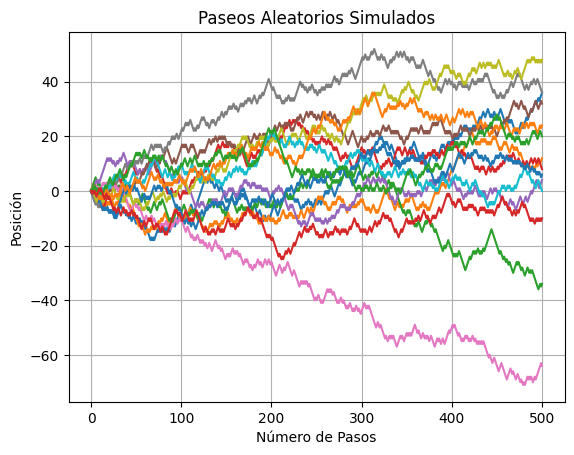

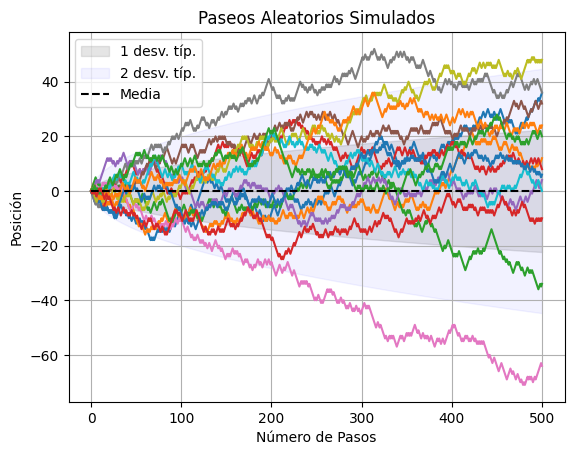

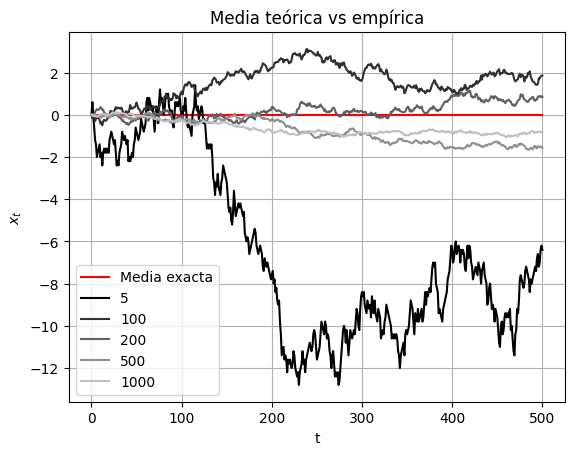

In [13]:

paseos= simular_PAS(p,n,reps)
graficar_PAS1(paseos)
graficar_PAS2(paseos)
graficar_medias(p, n, lista_reps=[5, 100, 200, 500, 1000])